In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import ttest_ind, pointbiserialr

df = pd.read_parquet('../data/processed/telco_churn.parquet')

display(df.head())
display(df.info())
display(df.isnull().sum())

,customerID,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,tenure_group,customer_type,avg_monthly_per_tenure_month,fiber_optic_flag,electronic_check_flag,month_to_month_flag,SeniorCitizen
0,7639-LIAYI,Male,0,0,52,1,Yes,DSL,Yes,No,...,79.75,4217.8,0,37+ months,Existing,1.53,0,0,0,0
1,9803-FTJCG,Male,1,1,71,1,Yes,DSL,Yes,Yes,...,66.85,4748.7,0,37+ months,Existing,0.94,0,0,0,0
2,5160-UXJED,Male,0,1,17,1,No,DSL,No,No,...,44.60,681.4,0,13-24 months,Existing,2.62,0,0,0,0
3,6122-EFVKN,Male,0,1,24,0,No phone service,DSL,Yes,No,...,35.75,830.8,0,13-24 months,Existing,1.49,0,0,0,0
4,3583-EKAPL,Male,0,0,1,1,No,DSL,No,No,...,55.00,55.0,1,1-6 months,Existing,55.00,0,1,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   customerID                    7043 non-null   string  
 1   gender                        7043 non-null   category
 2   Partner                       7043 non-null   int8    
 3   Dependents                    7043 non-null   int8    
 4   tenure                        7043 non-null   int64   
 5   PhoneService                  7043 non-null   int8    
 6   MultipleLines                 7043 non-null   category
 7   InternetService               7043 non-null   category
 8   OnlineSecurity                7043 non-null   category
 9   OnlineBackup                  7043 non-null   category
 10  DeviceProtection              7043 non-null   category
 11  TechSupport                   7043 non-null   category
 12  StreamingTV                   7043 non-null   ca

None

customerID                       0
gender                           0
Partner                          0
Dependents                       0
tenure                           0
PhoneService                     0
MultipleLines                    0
InternetService                  0
OnlineSecurity                   0
OnlineBackup                     0
DeviceProtection                 0
TechSupport                      0
StreamingTV                      0
StreamingMovies                  0
Contract                         0
PaperlessBilling                 0
PaymentMethod                    0
MonthlyCharges                   0
TotalCharges                     0
Churn                            0
tenure_group                     0
customer_type                    0
avg_monthly_per_tenure_month    11
fiber_optic_flag                 0
electronic_check_flag            0
month_to_month_flag              0
SeniorCitizen                    0
dtype: int64

In [12]:
# Univariate Analysis
# Распределение целевой переменной Churn
total_customers = df['Churn'].count()
churn_yes = (df['Churn'] == 1).sum()
churn_no = (df['Churn'] == 0).sum()

fig = px.pie(df, names='Churn', title='Распределение оттока клиентов (Churn)',
             color_discrete_sequence=px.colors.qualitative.Set2,
             hole=0.4)
fig.update_traces(textinfo='percent+label')
fig.update_layout(height=500)

print(f"Всего клиентов: {total_customers}")
print(f"Оставшихся (Churn = 1): {churn_no} - {round(churn_no / total_customers * 100.0, 2)}%") 
print(f"Ушедших (Churn = 0): {churn_yes} - {round(churn_yes / total_customers * 100.0, 2)}%")
fig.show()

Всего клиентов: 7043
Оставшихся (Churn = 1): 5174 - 73.46%
Ушедших (Churn = 0): 1869 - 26.54%


In [ ]:
# Общее распределение числовых переменных

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    fig = px.histogram(df, x=col,
                        marginal='box',
                        nbins=50,
                        title=f'Общее распределение {col}',
                        color_discrete_sequence=['blue'],
                        barmode='overlay')
    fig.update_layout(height=500)

    print(f'Описание {col}:')
    display(df[col].describe())
    fig.show()

Описание tenure


count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Описание MonthlyCharges


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Описание TotalCharges


count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [35]:
# Таблицы и графики частот для категориальных признаков

categorical_cols = [col for col in df.columns if col not in numerical_cols 
                    and col not in ['customerID', 'Churn', 'customer_type', 
                                    'avg_monthly_per_tenure_month', 'fiber_optic_flag', 
                                    'electronic_check_flag', 'month_to_month_flag']]

for col in categorical_cols:
    freq = df[col].value_counts().head(10)
    percent = df[col].value_counts(normalize=True).head(10) * 100
    table = pd.concat([freq, percent.round(2)], axis=1, keys=['Count', 'Percent (%)'])

    fig = px.pie(df, names=col, title=f'Распределение {col}',
             color_discrete_sequence=px.colors.qualitative.Set2,
             hole=0.4)
    fig.update_traces(textinfo='percent+label')
    fig.update_layout(height=500)

    print(f'Распределение {col}:')
    display(table)
    fig.show()

Распределение gender:


,Count,Percent (%)
gender,,
Male,3555,50.48
Female,3488,49.52


Распределение Partner:


,Count,Percent (%)
Partner,,
0,3641,51.7
1,3402,48.3


Распределение Dependents:


...

,Count,Percent (%)
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


Распределение tenure_group:


,Count,Percent (%)
tenure_group,,
37+ months,3001,42.61
1-6 months,1470,20.87
13-24 months,1024,14.54
25-36 months,832,11.81
7-12 months,705,10.01
New customer,11,0.16


Распределение SeniorCitizen:


,Count,Percent (%)
SeniorCitizen,,
0,5901,83.79
1,1142,16.21


In [ ]:
# Bivariate Analysis
# Распределение числовых переменных с разделением по Churn

for col in numerical_cols:
    fig = px.histogram(df, x=col, color='Churn', 
                        marginal='box',
                        nbins=50,
                        title=f'Распределение {col} по Churn',
                        color_discrete_sequence=px.colors.qualitative.Set2,
                        barmode='overlay')
    fig.update_layout(height=500)

    print(f'Описание {col} по Churn:')
    display(df.groupby('Churn')[col].describe())
    fig.show()

Описание tenure по Churn


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Описание MonthlyCharges по Churn


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Описание TotalCharges по Churn


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


In [30]:
# Статистические тесты: влияние числовых признаков на Churn

results = []

for col in numerical_cols:
    group_yes = df[df['Churn'] == 1][col]
    group_no  = df[df['Churn'] == 0][col]
    
    # t-тест
    t_stat, p_value_t = ttest_ind(group_yes, group_no, equal_var=False, nan_policy='omit')
    
    # Point-Biserial Correlation
    corr, p_value_pb = pointbiserialr(df['Churn'], df[col])
    
    # Интерпретация силы связи
    if abs(corr) < 0.1:
        strength = "очень слабая"
    elif abs(corr) < 0.3:
        strength = "слабая"
    elif abs(corr) < 0.5:
        strength = "средняя"
    else:
        strength = "сильная"
    
    results.append({
        'Признак': col,
        'Mean (No Churn)': round(group_no.mean(), 2),
        'Mean (Yes Churn)': round(group_yes.mean(), 2),
        'Разница средних': round(group_yes.mean() - group_no.mean(), 2),
        't-статистика': round(t_stat, 4),
        'p-value (t-test)': f"{p_value_t:.6f}",
        'Корреляция (Point-Biserial)': round(corr, 4),
        'Сила связи': strength,
        'p-value (корр.)': f"{p_value_pb:.6f}"
    })

# Вывод результатов в виде таблицы
print("Статистические тесты влияния числовых признаков на отток")
stats_df = pd.DataFrame(results)
display(stats_df)

Статистические тесты влияния числовых признаков на отток


,Признак,Mean (No Churn),Mean (Yes Churn),Разница средних,t-статистика,p-value (t-test),Корреляция (Point-Biserial),Сила связи,p-value (корр.)
0,tenure,37.57,17.98,-19.59,-34.8238,0.000000,-0.3522,средняя,0.000000
1,MonthlyCharges,61.27,74.44,13.18,18.4075,0.000000,0.1934,слабая,0.000000
2,TotalCharges,2549.91,1531.80,-1018.12,-18.7066,0.000000,-0.1983,слабая,0.000000


In [ ]:
# Анализ оттока (Churn = 1) по категориям

for col in categorical_cols:
    is_numeric = False
    if pd.api.types.is_numeric_dtype(df[col]):
        is_numeric = True
        df[col] = df[col].astype('category')

    churn_rate = (df.groupby(col, observed=False)['Churn']
                    .mean()
                    .mul(100)           
                    .round(2)
                    .reset_index(name='Churn_Rate'))
    
    churn_rate = churn_rate.sort_values('Churn_Rate', ascending=False)
    churn_rate_display = churn_rate[[col, 'Churn_Rate']]
    
    fig = px.bar(
        churn_rate,
        x=col,
        y='Churn_Rate',
        title=f'Процент оттока (Churn = 1) по {col}',
        color='Churn_Rate',                    
        color_continuous_scale='RdYlGn_r',       
        text='Churn_Rate',
        labels={'Churn_Rate': 'Процент ушедших (%)', col: col}        
    )
    
    fig.update_traces(texttemplate='%{y:.2f}%')
    
    print(f"\nChurn Rate по {col}:")
    display(churn_rate_display.style.hide(axis="index"))
    fig.show()
    
    if is_numeric:
        df[col] = df[col].astype('int8')



Churn Rate по gender:


gender,Churn_Rate
Female,26.920000
Male,26.160000



Churn Rate по Partner:


Partner,Churn_Rate
0,32.960000
1,19.660000



Churn Rate по Dependents:


...

PaymentMethod,Churn_Rate
Electronic check,45.290000
Mailed check,19.110000
Bank transfer (automatic),16.710000
Credit card (automatic),15.240000



Churn Rate по tenure_group:


tenure_group,Churn_Rate
1-6 months,53.330000
7-12 months,35.890000
13-24 months,28.710000
25-36 months,21.630000
37+ months,11.930000
New customer,0.000000



Churn Rate по SeniorCitizen:


SeniorCitizen,Churn_Rate
1,41.680000
0,23.610000


In [69]:
# Multivariate Analysis
# Анализ комбинаций важных признаков

combinations = [
    ('Contract', 'PaymentMethod'),
    ('Contract', 'InternetService'),
    ('Contract', 'TechSupport'),
    ('PaymentMethod', 'InternetService'),
    ('SeniorCitizen', 'Contract'),
    ('tenure_group', 'Contract')
]

for col1, col2 in combinations:
    combo = (df.groupby([col1, col2], observed=False)['Churn']
             .value_counts(normalize=True)
             .unstack(fill_value=0))
    
    if 1 in combo.columns:
        rate = (combo[1] * 100).round(2).reset_index()
        rate.columns = [col1, col2, 'Churn_Rate']
        rate = rate.sort_values('Churn_Rate', ascending=False)
        
        display(rate.head(10).reset_index(drop=True).style.format({'Churn_Rate': '{:.2f}%'})
                .set_caption(f"Топ 10 комбинаций по оттоку: {col1} + {col2}"))
        
        fig = px.bar(rate.head(10), 
                     x=col1, 
                     y='Churn_Rate', 
                     color=col2,
                     barmode='group',
                     title=f'Churn Rate по комбинации {col1} + {col2} (Топ-10)',
                     text='Churn_Rate')
        fig.update_traces(texttemplate='%{text:.1f}%')
        fig.update_layout(height=550, xaxis_tickangle=45)
        fig.show()

,Contract,PaymentMethod,Churn_Rate
0,Month-to-month,Electronic check,53.73%
1,Month-to-month,Bank transfer (automatic),34.13%
2,Month-to-month,Credit card (automatic),32.78%
3,Month-to-month,Mailed check,31.58%
4,One year,Electronic check,18.44%
5,One year,Credit card (automatic),10.30%
6,One year,Bank transfer (automatic),9.72%
7,Two year,Electronic check,7.74%
8,One year,Mailed check,6.82%
9,Two year,Bank transfer (automatic),3.37%


,Contract,InternetService,Churn_Rate
0,Month-to-month,Fiber optic,54.61%
1,Month-to-month,DSL,32.22%
2,One year,Fiber optic,19.29%
3,Month-to-month,No,18.89%
4,One year,DSL,9.30%
5,Two year,Fiber optic,7.23%
6,One year,No,2.47%
7,Two year,DSL,1.91%
8,Two year,No,0.78%


,Contract,TechSupport,Churn_Rate
0,Month-to-month,No,50.37%
1,Month-to-month,Yes,30.70%
2,Month-to-month,No internet service,18.89%
3,One year,No,14.72%
4,One year,Yes,13.59%
5,Two year,No,5.93%
6,Two year,Yes,3.53%
7,One year,No internet service,2.47%
8,Two year,No internet service,0.78%


,PaymentMethod,InternetService,Churn_Rate
0,Electronic check,Fiber optic,53.23%
1,Mailed check,Fiber optic,42.64%
2,Electronic check,DSL,31.94%
3,Bank transfer (automatic),Fiber optic,28.95%
4,Credit card (automatic),Fiber optic,25.29%
5,Mailed check,DSL,20.72%
6,Electronic check,No,12.30%
7,Credit card (automatic),DSL,12.12%
8,Mailed check,No,9.58%
9,Bank transfer (automatic),DSL,9.36%


,SeniorCitizen,Contract,Churn_Rate
0,1,Month-to-month,54.65%
1,0,Month-to-month,39.57%
2,1,One year,15.26%
3,0,One year,10.68%
4,1,Two year,4.14%
5,0,Two year,2.71%


,tenure_group,Contract,Churn_Rate
0,1-6 months,Month-to-month,55.20%
1,7-12 months,Month-to-month,42.00%
2,13-24 months,Month-to-month,37.72%
3,25-36 months,Month-to-month,32.51%
4,37+ months,Month-to-month,29.64%
5,37+ months,One year,12.97%
6,7-12 months,One year,10.59%
7,1-6 months,One year,10.53%
8,13-24 months,One year,8.12%
9,25-36 months,One year,8.00%


In [64]:
# ====================== FEATURE ENGINEERING INSIGHTS ======================
print("=== FEATURE ENGINEERING INSIGHTS ===\n")
print("Анализ влияния созданных признаков на отток\n")

# Создаём новые признаки (если их ещё нет в данных)
if 'tenure_group' not in df.columns:
    df['tenure_group'] = pd.cut(df['tenure'], 
                                bins=[-1, 0, 6, 12, 24, 36, float('inf')],
                                labels=['New Client', '1-6 months', '7-12 months', 
                                        '13-24 months', '25-36 months', '37+ months'])

if 'avg_monthly_per_tenure_month' not in df.columns:
    df['avg_monthly_per_tenure_month'] = round(df['MonthlyCharges'] / df['tenure'].replace(0, np.nan), 2)

# Создаём флаги
df['high_monthly_flag'] = (df['MonthlyCharges'] > 80).astype(int)
df['fiber_optic_flag'] = (df['InternetService'] == 'Fiber optic').astype(int)
df['electronic_check_flag'] = (df['PaymentMethod'] == 'Electronic check').astype(int)
df['month_to_month_flag'] = (df['Contract'] == 'Month-to-month').astype(int)
df['senior_citizen_flag'] = df['SeniorCitizen'].astype(int)

print("Новые признаки успешно созданы.\n")

=== FEATURE ENGINEERING INSIGHTS ===

Анализ влияния созданных признаков на отток

Новые признаки успешно созданы.



1. Влияние tenure_group на отток:


Churn,Churn_Rate
tenure_group,
1-6 months,53.33
7-12 months,35.89
13-24 months,28.71
25-36 months,21.63
37+ months,11.93
New customer,NaN


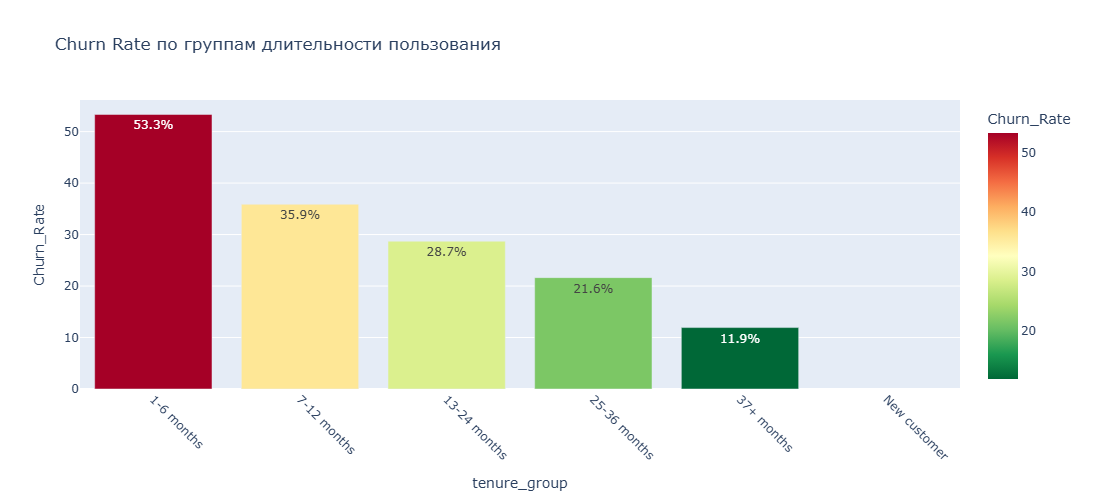

In [66]:
# 1. Анализ tenure_group
print("1. Влияние tenure_group на отток:")
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].value_counts(normalize=True).unstack()
tenure_churn['Churn_Rate'] = tenure_churn.get(1, 0) * 100
tenure_churn = tenure_churn.sort_values('Churn_Rate', ascending=False)

display(tenure_churn[['Churn_Rate']].round(2))

fig = px.bar(tenure_churn.reset_index(), 
             x='tenure_group', 
             y='Churn_Rate',
             title='Churn Rate по группам длительности пользования',
             color='Churn_Rate',
             color_continuous_scale='RdYlGn_r',
             text='Churn_Rate')
fig.update_traces(texttemplate='%{text:.1f}%')
fig.update_layout(height=500, xaxis_tickangle=45)
fig.show()


2. Влияние среднего платежа за месяц стажа (avg_monthly_per_tenure_month):
Churn Rate по квантилям среднего платежа за месяц стажа:


Churn,Churn_Rate
avg_monthly_bin,
Q1 (Lowest),3.32
Q2,10.10
Q3,24.01
Q4,36.56
Q5 (Highest),59.13


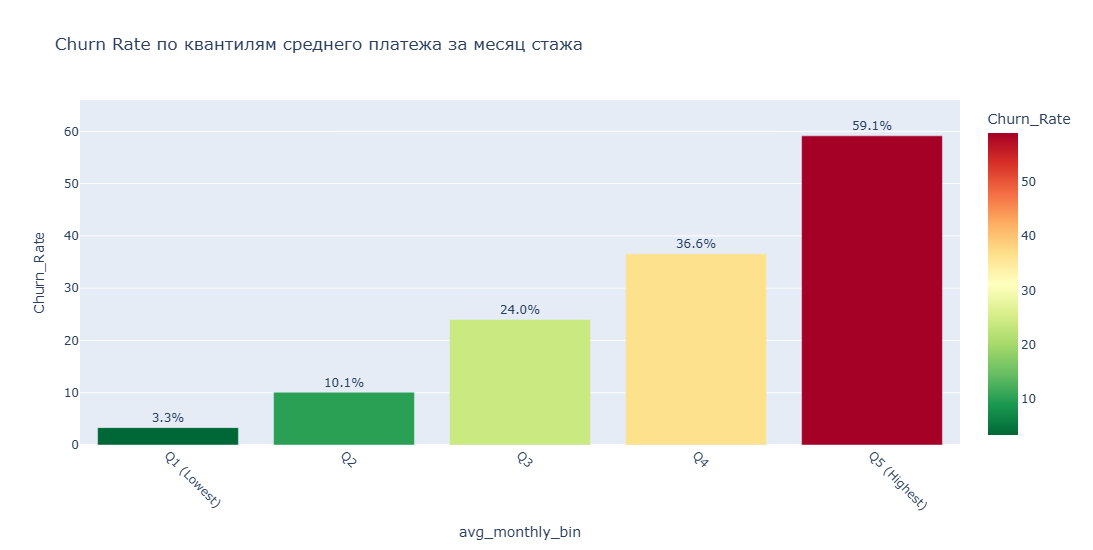

In [71]:
# 2. Анализ avg_monthly_per_tenure_month
print("\n2. Влияние среднего платежа за месяц стажа (avg_monthly_per_tenure_month):")

# Создаём bins вручную, чтобы избежать Interval
df['avg_monthly_bin'] = pd.qcut(df['avg_monthly_per_tenure_month'], 
                                q=5, 
                                duplicates='drop',
                                labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])

avg_churn = df.groupby('avg_monthly_bin', observed=True)['Churn'].value_counts(normalize=True).unstack()

if 1 in avg_churn.columns:
    avg_churn['Churn_Rate'] = (avg_churn[1] * 100).round(2)
    
    print("Churn Rate по квантилям среднего платежа за месяц стажа:")
    display(avg_churn[['Churn_Rate']])
    
    # Исправленный график
    fig = px.bar(avg_churn.reset_index(), 
                 x='avg_monthly_bin', 
                 y='Churn_Rate',
                 title='Churn Rate по квантилям среднего платежа за месяц стажа',
                 color='Churn_Rate',
                 color_continuous_scale='RdYlGn_r',
                 text='Churn_Rate')
    
    fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig.update_layout(height=550, xaxis_tickangle=45)
    fig.show()
else:
    print("Не удалось рассчитать Churn Rate для этого признака.")